# Uganda's tourism: who comes, what they spend, and when
**Ministry of Tourism, Wildlife and Antiquities**, Statistical Abstract 2025 (2020–2024): arrivals by month, purpose and country; national park visits; gorilla and chimpanzee permits; hotel occupancy.
**Uganda Bureau of Statistics**, Statistical Abstracts 2017 and 2020 (2012–2019): arrivals by purpose; national park visits by park and by month.
**UN Tourism**: inbound arrivals and travel receipts for Uganda and nine African peers.
**Rainfall**: CHIRPS regional rainfall from the uganda-rainfall-analysis project.

Tables were extracted from the PDFs by `scripts/extract_tables.py`, each checked against its printed totals.

**Questions**
1. Who actually comes to Uganda, and how comparable are the arrival counts over time?
2. How have tourism earnings recovered since COVID-19, against Uganda's peers?
3. How have national park visits grown, and who drives the growth?
4. When do visitors come, and does that follow the rainy seasons?
5. How much of Uganda's most valuable product, gorilla tracking, goes unsold?

In [1]:
import sys, warnings
sys.path.insert(0, '../scripts')
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from tourism import (PROC, MON, GORILLA_PERMIT_USD, EAST_AFRICA, load_parks_annual, load_parks_monthly, load_parks_category,
                     load_arrivals_purpose, load_arrivals_monthly, load_arrivals_country, load_arrivals_region,
                     load_overseas_markets, load_gorilla, load_chimp,
                     load_hotels, load_untourism, load_rainfall)

INK, GREY, LIGHT, GRID = '#1a1a1a', '#6b6b6b', '#b5b3ad', '#e6e4df'
WET, DRY, GREEN = '#2b6c9e', '#c4572e', '#3d8b5f'
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'medium',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c4', 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'xtick.color': GREY, 'ytick.color': GREY, 'axes.labelcolor': GREY,
    'legend.frameon': False,
})
pd.set_option('display.width', 200)

## 1. Who comes: the arrival counts and their breaks

In [2]:
ap = load_arrivals_purpose().set_index('year')
cols = ['Leisure and holiday', 'Business and professional', 'Visiting friends and relatives', 'Other']
share = ap[cols].div(ap[cols].sum(axis=1), axis=0) * 100
print('Tourist arrivals by purpose of visit (thousands) and leisure share')
print(pd.concat([ap[cols].sum(axis=1).div(1000).rename('total, thousand'), ap['Leisure and holiday'].div(1000).rename('leisure, thousand'),
                 share['Leisure and holiday'].rename('leisure share %'), ap['source']], axis=1).round(1).to_string())

ut = load_untourism('arrivals')
print('\nThree counts of 2019 arrivals:')
print('  UN Tourism (overnight visitors, as reported by Uganda):', f"{ut.loc[2019, 'Uganda'] * 1000:,.0f}")
print('  UBOS, total arrivals at eight ports, PISCES system:     1,040,000')
print('  UBOS, of which visitors (non-resident):                   657,037')
print('  UBOS says 2019 cannot be compared with earlier years, which used arrival cards')

ar = load_arrivals_region()
ac = load_arrivals_country()
y = ac[2024]
neigh = ['Kenya', 'Rwanda', 'South Sudan', 'Congo, Democratic Republic of the', 'Burundi', 'Tanzania, United Republic of']
t24 = ar.loc[2024, 'TOTAL']
print(f"\n2024: {t24:,.0f} arrivals; Africa {100 * ar.loc[2024, 'AFRICA'] / t24:.0f}%; six neighbours {100 * y[neigh].sum() / t24:.0f}%; "
      f"Kenya and Rwanda {100 * y[['Kenya', 'Rwanda']].sum() / t24:.0f}%")
over = ['AMERICAS', 'EAST ASIA AND THE PACIFIC', 'EUROPE', 'MIDDLE EAST', 'SOUTH ASIA']
print('Arrivals from outside Africa:'); print(ar[over].assign(total=ar[over].sum(axis=1)).astype(int).to_string())
print(f"Outside Africa in 2024: {ar.loc[2024, over].sum():,.0f} ({100 * ar.loc[2024, over].sum() / t24:.0f}%)")
om = load_overseas_markets()
print('\nTop overseas markets, 2024:'); print(om[om['year'] == 2024].set_index('rank')[['market', 'arrivals']].to_string())

Tourist arrivals by purpose of visit (thousands) and leisure share
      total, thousand  leisure, thousand  leisure share %                                 source
year                                                                                            
2012           1197.0              148.0             12.4              UBOS 2017 (arrival cards)
2013           1206.0              188.0             15.6              UBOS 2017 (arrival cards)
2014           1266.0              220.0             17.4              UBOS 2017 (arrival cards)
2015           1303.0              208.0             16.0              UBOS 2017 (arrival cards)
2016           1323.0              237.0             17.9              UBOS 2017 (arrival cards)
2020            473.1               10.8              2.3  MTWA 2025 (PISCES immigration system)
2021            512.9               46.2              9.0  MTWA 2025 (PISCES immigration system)
2022            814.5               95.4             11.7  M

Most "tourist arrivals" are not holidaymakers. In 2024 only about 19% came for leisure and holidays; the rest came to visit friends and relatives, for business, study, health or other reasons. Nine in ten came from Africa, and Kenya and Rwanda alone sent about 63%. Only about 140,000 arrivals (10%) came from outside Africa, led by India, the United States, China and the United Kingdom. Arrival counts also changed basis in 2019, from paper arrival cards to the PISCES immigration system, and the published 2019 figures differ by a factor of more than two depending on the definition. Leisure arrivals (265,000 in 2024 against 148,000–237,000 in 2012–2016) are the most useful single measure of holiday tourism, but even they cross that break.

## 2. Earnings and recovery, against the peers
Travel receipts from the balance of payments are the most comparable measure across countries (UN Tourism). They count all visitor spending, including students, patients and business travellers, so they measure the whole visitor economy rather than holiday tourism alone.

Travel receipts, US$ million
country  Uganda   Kenya  Tanzania  Rwanda  Ethiopia
year                                               
2015     1037.0   724.0    1902.0   338.0     405.0
2016     1102.0   824.0    2132.0   363.0     347.0
2017      941.0   916.0    2250.0   381.0     436.0
2018     1506.0  1072.0    2449.0   392.0     968.0
2019     1385.0  1007.0    2604.0   458.0     786.0
2020      562.0   541.0     715.0   120.0    1033.0
2021      984.0   844.0    1310.0   150.0     965.0
2022     1071.0  1110.0    2528.0   400.0    1175.0
2023     1303.0  1005.0    3374.0   564.0    1104.0

2023 receipts as % of 2019:
country
Zimbabwe         56.0
Botswana         56.0
South Africa     68.0
Uganda           94.0
Zambia           98.0
Namibia          99.0
Kenya           100.0
Rwanda          123.0
Tanzania        130.0
Ethiopia        140.0


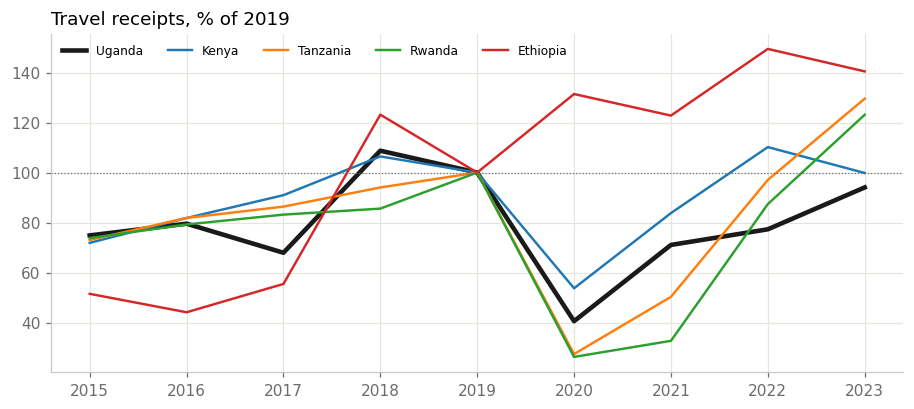

In [3]:
tr = load_untourism('travel')
rec = (tr.loc[2023] / tr.loc[2019] * 100).sort_values()
print('Travel receipts, US$ million'); print(tr.loc[2015:2023, ['Uganda', 'Kenya', 'Tanzania', 'Rwanda', 'Ethiopia']].round(0).to_string())
print('\n2023 receipts as % of 2019:'); print(rec.round(0).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
for c in ['Uganda', 'Kenya', 'Tanzania', 'Rwanda', 'Ethiopia']:
    s = tr[c].loc[2015:2023] / tr.loc[2019, c] * 100
    ax.plot(s.index, s, lw=3 if c == 'Uganda' else 1.6, color=INK if c == 'Uganda' else None, label=c)
ax.axhline(100, color=GREY, lw=.8, ls=':')
ax.set_title('Travel receipts, % of 2019'); ax.legend(ncol=5, fontsize=8); plt.show()

Uganda's visitor earnings were back to about 94% of their 2019 level in 2023, behind Kenya (100%), Rwanda (123%), Tanzania (130%) and Ethiopia (140%), and ahead of southern Africa's safari destinations (Botswana and Zimbabwe 56%, South Africa 68%). The Ministry reports US$1.28 billion in 2024 and US$1.62 billion in 2025, which would put Uganda above its 2019 level, but those figures are not yet in the UN Tourism series, so they cannot be compared like for like.

## 3. National parks: a consistent series since 2012
Uganda Wildlife Authority's gate counts are the most consistent tourism series available: the same source and definition throughout.

National park visits:
year
2012    182149
2013    213950
2014    202885
2015    215558
2016    245725
2017    285671
2018    325345
2019    323861
2020    101331
2021    189988
2022    367869
2023    387914
2024    436767

2024 as % of 2019: 135%
Murchison, Queen Elizabeth and Bwindi: 66–76% of all visits every year

Visitors by category:
category  East African Residents  Foreign Non Residents  Foreign Residents  Others  Students
year                                                                                        
2016                       62142                  95949              15778    1557     70299
2018                        <NA>                 150931               <NA>    <NA>      <NA>
2019                        <NA>                 153911               <NA>    <NA>      <NA>
2020                       44581                  42714               8611    1596      3829
2021                       89635                  56112              13731   25238      5272
2022    

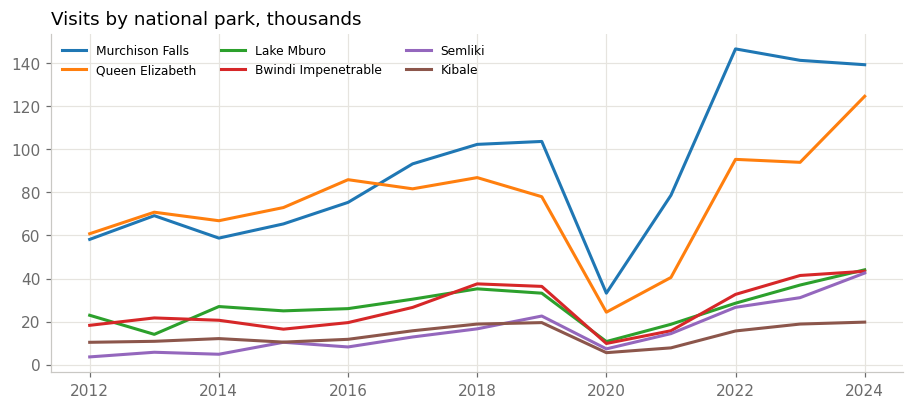

In [4]:
pa = load_parks_annual()
tot = pa.groupby('year')['visits'].sum()
print('National park visits:'); print(tot.astype(int).to_string())
print(f"\n2024 as % of 2019: {100 * tot[2024] / tot[2019]:.0f}%")
by = pa.pivot_table(index='year', columns='park', values='visits')
top3 = by[['Murchison Falls', 'Queen Elizabeth', 'Bwindi Impenetrable']].sum(axis=1) / by.sum(axis=1)
print(f"Murchison, Queen Elizabeth and Bwindi: {100 * top3.min():.0f}–{100 * top3.max():.0f}% of all visits every year")

pc = load_parks_category().pivot_table(index='year', columns='category', values='visits')
print('\nVisitors by category:'); print(pc.astype('Int64').to_string())
fnr = pc['Foreign Non Residents']
print(f"\nForeign non-resident visits 2024 as % of 2019: {100 * fnr[2024] / fnr[2019]:.0f}%")
grow = pc.loc[2024] - pd.Series({'Foreign Non Residents': fnr[2019]})
print(f"Students: {pc.loc[2024, 'Students']:,.0f} in 2024 (27.6% of visits); 2016: {pc.loc[2016, 'Students']:,.0f}")

fig, ax = plt.subplots(figsize=(10, 4))
order = by.loc[2024].sort_values(ascending=False).index[:6]
for p in order:
    ax.plot(by.index, by[p] / 1000, lw=2, label=p)
ax.set_title('Visits by national park, thousands'); ax.legend(ncol=3, fontsize=8); plt.show()

Park visits grew steadily from about 180,000 in 2012 to 324,000 in 2019, collapsed to 101,000 in 2020, and reached a record 437,000 in 2024, 35% above 2019. But the growth is mostly domestic: foreign non-resident visitors (160,000 in 2024) are only about 4% above their 2019 level, while Ugandan students (120,000) and East African residents drive the rest. Three parks, Murchison Falls, Queen Elizabeth and Bwindi, take about 70% of all visits every year.

## 4. When visitors come

     park visits, % of year  gorilla permits sold, %  all arrivals, % of year  rain, Western (mm)  rain, Northern (mm)
Jan                     6.7                     63.1                      7.9                43.4                 12.4
Feb                     5.6                     74.4                      7.3                48.8                 20.1
Mar                     5.0                     33.7                      7.4               108.3                 70.7
Apr                     5.7                     23.0                      7.7               151.0                134.5
May                     6.5                     30.3                      8.0               105.9                142.5
Jun                     8.2                     74.1                      8.2                56.4                122.3
Jul                    14.2                    101.5                      9.0                49.4                136.7
Aug                    15.2                    1

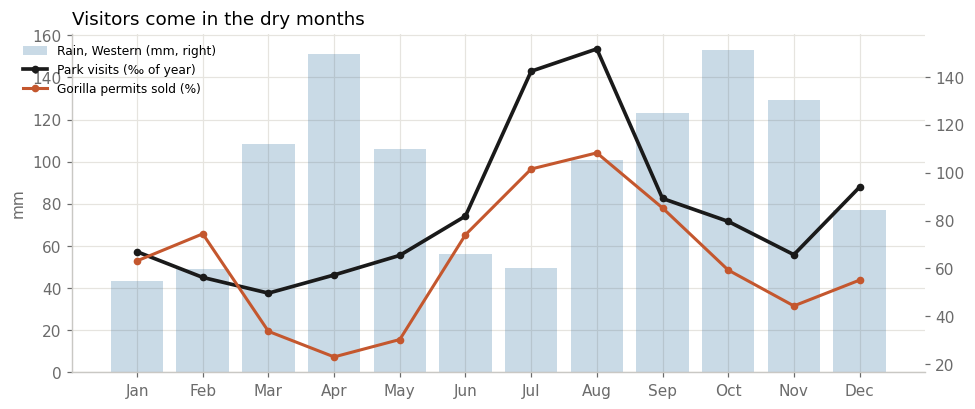


Hotel room occupancy by month (%):
month  1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   10.0  11.0  12.0
year                                                                         
2020   38.5  30.9  21.3   2.0   1.4   4.1  20.7  23.9  23.3  23.4  26.5  24.8
2021   35.2  36.1  35.7  40.1  48.0  44.7  32.0  20.2  36.5  28.3  25.9  31.2
2022   30.2  32.6  46.9  34.2  44.1  41.6  50.6  53.9  51.5  50.8  50.5  52.2
2023   47.3  44.4  49.3  48.8  46.4  46.5  53.5  56.4  60.9  62.4  63.6  48.2
2024   53.3  53.8  52.1  54.4  52.6  53.5  52.6  53.0  53.2   NaN   NaN   NaN
By region (%):
year      2020  2021  2022  2023  2024
scope                                 
Central   18.0  26.1  30.1  34.5  49.6
Eastern   20.6  26.3  50.2  58.1  46.6
Kampala   18.2  41.4  61.4  53.6  68.3
Northern  24.8  35.2  48.5  52.7  46.5
Western   22.5  34.3  33.8  65.2  51.2


In [5]:
pm = load_parks_monthly()
normal = pm[~pm['year'].isin([2020, 2021])]
ps = normal.assign(s=normal['visits'] / normal.groupby('year')['visits'].transform('sum') * 100).groupby('month')['s'].mean()
g = load_gorilla()
gu = g[g['year'].isin([2023, 2024])].groupby('month')[['sold', 'available']].sum()
gu = gu['sold'] / gu['available'] * 100
am = load_arrivals_monthly()
an = am[am['year'].isin([2023, 2024])]
as_ = an.assign(s=an['arrivals'] / an.groupby('year')['arrivals'].transform('sum') * 100).groupby('month')['s'].mean()
rain_w, rain_n = load_rainfall('Western'), load_rainfall('Northern')
seas = pd.DataFrame({'park visits, % of year': ps, 'gorilla permits sold, %': gu, 'all arrivals, % of year': as_,
                     'rain, Western (mm)': rain_w, 'rain, Northern (mm)': rain_n})
seas.index = MON
print(seas.round(1).to_string())
print(f"\nJuly + August: {ps.loc[[7, 8]].sum():.0f}% of park visits; March: {ps.loc[3]:.1f}%")
for k in ['park visits, % of year', 'gorilla permits sold, %']:
    r, p = spearmanr(seas[k], seas['rain, Western (mm)'])
    print(f"{k} vs Western rainfall: rank correlation {r:+.2f} (p = {p:.2f}, 12 months)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(MON, rain_w, color=WET, alpha=.25, label='Rain, Western (mm, right)')
ax2 = ax.twinx(); ax.set_ylabel('mm'); ax2.grid(False)
ax2.plot(MON, ps * 10, color=INK, lw=2.4, marker='o', ms=4, label='Park visits (‰ of year)')
ax2.plot(MON, gu, color=DRY, lw=2, marker='o', ms=4, label='Gorilla permits sold (%)')
ax.set_title('Visitors come in the dry months'); fig.legend(loc='upper left', bbox_to_anchor=(.07, .88), fontsize=8)
plt.show()

ho = load_hotels()
hn = ho[ho['scope'] == 'national'].pivot_table(index='year', columns='month', values='occupancy')
print('\nHotel room occupancy by month (%):'); print(hn.round(1).to_string())
print('By region (%):'); print(ho[ho['scope'] != 'national'].pivot_table(index='scope', columns='year', values='occupancy').round(1).to_string())

Visitors to the parks are concentrated in a few months: July and August alone bring 29% of the year's park visits, and about 90% of gorilla permits sold in those months in 2024 (in 2023 recorded sales exceeded the listed permits by up to a third, an inconsistency in the source), while March brings 5% of visits and gorilla permits in March–May sell only a quarter to a third. The quietest months include the wettest in the south-west, where most gorilla and savannah parks lie, but across all twelve months the link to rainfall is weak (rank correlation −0.18 for park visits and −0.48 for gorilla bookings, neither significant): August is busy despite rain. The July–August peak matches European and North American summer holidays at least as well as the weather. Total arrivals show almost no seasonality, because most arrivals are regional visitors, not holidaymakers. Hotel occupancy also shows little seasonality in 2024 (52–54% every month), so the hotel survey appears to capture mainly urban and business hotels rather than safari lodges.

## 5. Gorilla permits: Uganda's most valuable product, partly unsold

      available   sold  sold %  unsold
year                                  
2020      57824  11346      19   46478
2021      56576   8029      14   48547
2022      56576  24438      43   32138
2023      56576  38836      68   17740
2024      71372  41468      58   29904

2024: 29,904 unsold permits. At the foreign non-resident rate (US$800) that is up to US$24 million of permit revenue; the true figure is lower, since some buyers pay East African or rest-of-Africa rates
Unsold in the wettest months (Mar–May, Nov), 2024: 16373 (55% of the year's unsold)

Chimpanzee tracking permits:
      available   sold  pct
year                       
2020      33030   4819   15
2021      32760   4998   15
2022      32760  12361   38
2023      32760  15695   48
2024      39528  17214   44


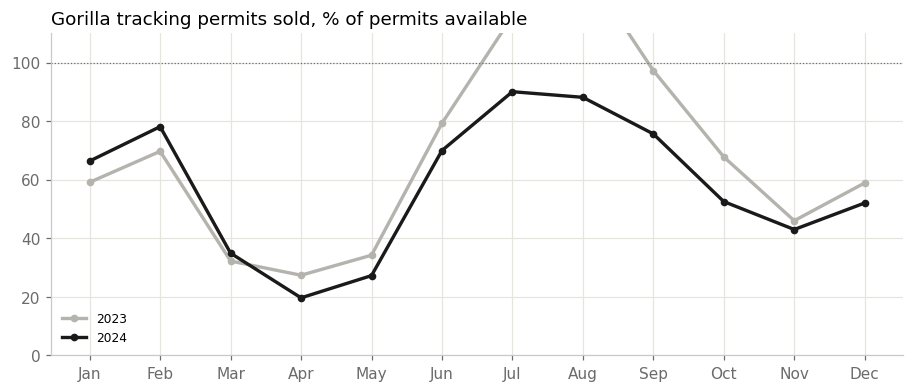

In [6]:
gy = g.groupby('year')[['available', 'sold']].sum()
gy['sold %'] = 100 * gy['sold'] / gy['available']
gy['unsold'] = gy['available'] - gy['sold']
print(gy.astype(int).to_string())
unsold = gy.loc[2024, 'unsold']
print(f"\n2024: {unsold:,.0f} unsold permits. At the foreign non-resident rate (US${GORILLA_PERMIT_USD['Foreign non-resident']}) that is "
      f"up to US${unsold * GORILLA_PERMIT_USD['Foreign non-resident'] / 1e6:.0f} million of permit revenue; the true figure is lower, "
      f"since some buyers pay East African or rest-of-Africa rates")
low = g[(g['year'] == 2024)].set_index('month')
print('Unsold in the wettest months (Mar–May, Nov), 2024:', int(low.loc[[3, 4, 5, 11], 'available'].sum() - low.loc[[3, 4, 5, 11], 'sold'].sum()),
      f"({100 * (low.loc[[3, 4, 5, 11], 'available'] - low.loc[[3, 4, 5, 11], 'sold']).sum() / unsold:.0f}% of the year's unsold)")
ch = load_chimp().groupby('year')[['available', 'sold']].sum()
print('\nChimpanzee tracking permits:'); print(ch.assign(pct=100 * ch['sold'] / ch['available']).round(0).astype(int).to_string())

fig, ax = plt.subplots(figsize=(10, 3.8))
for yr, col in [(2023, LIGHT), (2024, INK)]:
    x = g[g['year'] == yr].set_index('month')
    ax.plot(MON, 100 * x['sold'] / x['available'], marker='o', ms=4, lw=2.2, color=col, label=str(yr))
ax.axhline(100, color=GREY, lw=.8, ls=':'); ax.set_ylim(0, 110)
ax.set_title('Gorilla tracking permits sold, % of permits available'); ax.legend(fontsize=8); plt.show()

Uganda raised gorilla permit capacity by 26% in 2024, from 56,576 to 71,372 a year. Sales grew 7%, so the share sold fell from 69% to 58%, leaving about 30,000 permits unsold, worth up to about US$24 million at the foreign non-resident price. Permits sell well in July–September and go largely unsold in the wet months, so the extra capacity mostly added low-season supply. That points to demand in the wet season, not the number of permits, as the constraint.

## 6. Shocks

In [7]:
pmi = pm.set_index('date')['visits']
ami = am.set_index('date')['arrivals']
print('Ebola outbreak (20 September 2022 – 11 January 2023): monthly park visits and arrivals, 2022 against 2023')
w = pd.DataFrame({'park visits 2022': pmi.loc['2022'].values, 'park visits 2023': pmi.loc['2023'].values,
                  'arrivals 2022': ami.loc['2022'].values, 'arrivals 2023': ami.loc['2023'].values}, index=MON)
w['parks 2022/2023'] = w['park visits 2022'] / w['park visits 2023']
w['arrivals 2022/2023'] = w['arrivals 2022'] / w['arrivals 2023']
print(w.round(2).to_string())
print(f"\nPark visits, Oct–Dec 2022 as share of Oct–Dec 2023: {w.loc[['Oct', 'Nov', 'Dec'], 'park visits 2022'].sum() / w.loc[['Oct', 'Nov', 'Dec'], 'park visits 2023'].sum():.2f}; "
      f"Jan–Aug: {w.loc[MON[:8], 'park visits 2022'].sum() / w.loc[MON[:8], 'park visits 2023'].sum():.2f}")
by2 = pa.pivot_table(index='park', columns='year', values='visits')
print(f"Queen Elizabeth after the October 2023 attack on tourists: {by2.loc['Queen Elizabeth', 2023]:,.0f} visits in 2023, "
      f"{by2.loc['Queen Elizabeth', 2024]:,.0f} in 2024 ({100 * (by2.loc['Queen Elizabeth', 2024] / by2.loc['Queen Elizabeth', 2023] - 1):+.0f}%)")

Ebola outbreak (20 September 2022 – 11 January 2023): monthly park visits and arrivals, 2022 against 2023
     park visits 2022  park visits 2023  arrivals 2022  arrivals 2023  parks 2022/2023  arrivals 2022/2023
Jan           23402.0           28548.0        49554.0        92437.0             0.82                0.54
Feb           20242.0           23325.0        46882.0        82731.0             0.87                0.57
Mar           17374.0           19788.0        58372.0        90708.0             0.88                0.64
Apr           23903.0           25220.0        65319.0        91227.0             0.95                0.72
May           20695.0           28915.0        66429.0        99324.0             0.72                0.67
Jun           33633.0           27869.0        68521.0       102251.0             1.21                0.67
Jul           53987.0           52563.0        72082.0       116298.0             1.03                0.62
Aug           57965.0           60692.

COVID-19 cut park visits by 69% in 2020 and they did not regain 2019 levels until 2022. The Ebola outbreak of late 2022 left no clear mark at national level: park visits in October–December 2022 ran at about the same ratio to 2023 as the rest of that year, and arrivals held at about 70% of their 2023 level throughout late 2022. Queen Elizabeth National Park, where two foreign tourists and their guide were killed in October 2023, had a record 2024 (+33%). Annual and national figures can hide short or local effects, so these are weak tests.

In [8]:
seas.round(3).to_csv(PROC / 'seasonality.csv')
gy.to_csv(PROC / 'gorilla_by_year.csv')
tr.round(1).to_csv(PROC / 'travel_receipts_peers.csv')
print('saved')

saved
